# Subsurface flow, with random porosity coefficients
## KL-Expansion of the Covariance
## Single level in NGSolve

In [10]:
from ngsolve import *
from ngsolve.webgui import Draw
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


## The covariance kernel 

$$
C(\mathbf{x},\mathbf{y}) := \sigma^2 \exp \left( - \frac{\left\|\mathbf{x}-\mathbf{y}\right\|_p}{\ell}\right)
$$

where  
$\mathbf{x},\mathbf{y}\in D$ are two vectors of the finite element mesh points 

$\left\|\cdot\right\|_p$ denotes the $\ell_p$-norm in $\mathbb{R}^d$  
typically $p=1$ or $2$.  
We will stick with $p=1$, so $\left\|\cdot\right\|=\lvert \cdot \rvert$.  

**The parameters**  
$\sigma^2 = $ the variance,  
in subsurface flow, typicaly only $\sigma^2 \geq 1$  
in the papers we are modeling they all choose $\sigma^2 = 1$.

$ \ell = $ the correlation length,  
in subsurface flow typically $ \ell \leq 1 $  
in the papers we are modeling they all choose $ \ell = 0.3$.


## Eigenvalues and Eigenvectors from Giles paper

For the covariance above, with $p=1$ and $\sigma^2=1$, we have 

$$
C(\mathbf{x},\mathbf{y})=\exp\left(-\frac{\lvert\mathbf{x}-\mathbf{y}\rvert}{\ell}\right)
$$

and the paper says this covariance operator has analytic expressions for the eigenpairs as follows.


### 1-Dimensional Setup

$ D = (0,1) $ the domain of interest  
$ \lambda_n^{1D} $ the eigenvalues  
$ \varphi_n^{1D}(x) $ the eigenvectors  
the $1D$ notation will only be included when needed to distinguish between $1D$ and $2D$.

$$
\lambda_n = \frac{2\ell}{\ell^2 \omega_n^2 + 1},\qquad n\in \mathbb{N}
$$

and  

$$
\varphi_n(x) = A_n \left(\sin(\omega_n x)+ \ell \omega_n \cos(\omega_n x)\right),\qquad n\in\mathbb{N},
$$  

where $\left\{\omega_n \right\}_{n\in\mathbb{N}}$ are the (real) solutions of the transcedental equation

$$
\tan(\omega) = \frac{2\ell \omega}{\ell^2 \omega^2 - 1}
$$

and the constant $A_n$ is chosen so that $\|\varphi\|_{L_2(0,1)} = 1$.

### 2-Dimensional Setup

$$
\lambda_n^{2D} = \lambda_{i_n}^{1D} \lambda_{j_n}^{1D},\qquad \text{for some }i_n,j_n \in \mathbb{N}
$$

and

$$
\varphi_n^{2D}(\mathbf{x}) = \varphi_{i_n}^{1D}(x_1) \varphi_{j_n}^{1D}(x_2),\qquad \text{for some }i_n,j_n \in \mathbb{N}
$$

Note: For $\sigma^2$ different to 1, the eigenfunctions are the same as above and the eigenvalues (both in $1D$ and $2D$) are simply multiplied by $\sigma^2$.


Since we will need all of the eigenpairs for our KL-expansion, we will construct them now.

Given $\ell=0.3$, the equation to find $\left\{\omega_n\right\}_{n\in\mathbb{N}}$ becomes

$$
\tan(\omega)=\frac{0.6\omega}{0.09\omega^2 - 1}.
$$

we will find the $\left\{\omega_n\right\}_{n\in\mathbb{N}}$ via a root-finding numerical solver.

In [16]:

def find_omega(w, ell):
    return np.tan(w) - (ell * w) / (ell**2 * w**2 - 1)


def find_roots(ell, w_min=-30.0, w_max=30.0,
               samples_per_interval=200, tol=1e-10):
    """
    Find all numerical roots in [w_min, w_max] using Brent's method.

    The interval is split at:
      1. poles of tan(w)
      2. poles of ell*w / (ell**2*w**2 - 1)
    """
    if ell == 0:
        # Equation becomes tan(w) = 0
        k_min = int(np.ceil(w_min / np.pi))
        k_max = int(np.floor(w_max / np.pi))
        return np.arange(k_min, k_max + 1, dtype=float) * np.pi

    poles = []

    # Poles of tan(w): pi/2 + k*pi
    k_min = int(np.floor((w_min - np.pi / 2) / np.pi)) - 1
    k_max = int(np.ceil((w_max - np.pi / 2) / np.pi)) + 1

    for k in range(k_min, k_max + 1):
        pole = np.pi / 2 + k * np.pi
        if w_min < pole < w_max:
            poles.append(pole)

    # Poles of the rational term: w = +/- 1/ell
    for pole in (-1.0 / ell, 1.0 / ell):
        if w_min < pole < w_max:
            poles.append(pole)

    # Divide the full range into continuous intervals
    boundaries = np.array(
        [w_min] + sorted(set(poles)) + [w_max],
        dtype=float
    )

    roots = []
    epsilon = 1e-8

    for left, right in zip(boundaries[:-1], boundaries[1:]):
        # Stay slightly away from singular endpoints
        a = left + epsilon
        b = right - epsilon

        if a >= b:
            continue

        grid = np.linspace(a, b, samples_per_interval)
        values = find_omega(grid, ell)

        for x1, x2, y1, y2 in zip(
            grid[:-1], grid[1:], values[:-1], values[1:]
        ):
            if not (np.isfinite(y1) and np.isfinite(y2)):
                continue

            # Capture a root lying directly on a grid point
            if abs(y1) < tol:
                roots.append(x1)

            # Brent's method requires a sign-changing bracket
            if y1 * y2 < 0:
                result = sp.optimize.root_scalar(
                    find_omega,
                    args=(ell,),
                    bracket=(x1, x2),
                    method="brentq",
                    xtol=tol,
                    rtol=tol
                )

                if result.converged:
                    roots.append(result.root)

        if abs(values[-1]) < tol:
            roots.append(grid[-1])

    # Sort and remove numerical duplicates
    roots.sort()

    unique_roots = []
    for root in roots:
        if not unique_roots or abs(root - unique_roots[-1]) > 1e-7:
            unique_roots.append(root)

    return np.array(unique_roots)

roots = find_roots(ell=0.3, w_min=0, w_max=30)
omegas = roots[roots > 1e-8]
print(omegas)

[ 2.24966908  4.25447479  6.85071699  9.79230172 12.83791144 15.92349078
 19.02834916 22.1439678  25.26620846 28.39281763]


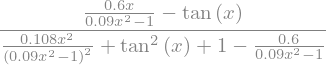

In [48]:
# Let's get the derivative analytically for our solver
import sympy as sym

x = sym.symbols('x')
f = sym.tan(x) - (0.6 * x) / (0.09 * x**2 - 1)
df = sym.diff(f, x)
step = - f / df
step